KPI Analysis

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data import clean_data

df = clean_data()
df.head(3)


c:\Users\sahil\OneDrive\Documents\Data_Analytics\Amazon_analysis\data.py:7: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(r"C:\Users\sahil\Downloads\Sales_Dataset\Amazon Sale Report.csv")
c:\Users\sahil\OneDrive\Documents\Data_Analytics\Amazon_analysis\data.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'],errors='coerce')


,order_id,date,status,fulfilment,sales_channel,ship-service-level,style,sku,category,size,...,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,b2b,fulfilled-by,month,year,revenue
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,4,2022,0.0
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,4,2022,406.0
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,4,2022,329.0


1. Total Revenue

In [48]:
total_revenue = df['amount'].sum()
total_revenue

np.float64(78592678.3)

In [49]:
monthly_revenue = df.groupby(["month"])["revenue"].sum().reset_index()
monthly_revenue

,month,revenue
0,3,98261.0
1,4,27847245.0
2,5,25326683.0
3,6,22762217.0


In [65]:
df.groupby('month')['amount'].sum()

month
3      101683.85
4    28838708.32
5    26226476.75
6    23425809.38
Name: amount, dtype: float64

In [50]:
df["month"].value_counts()

month
4    49067
5    42040
6    37697
3      171
Name: count, dtype: int64

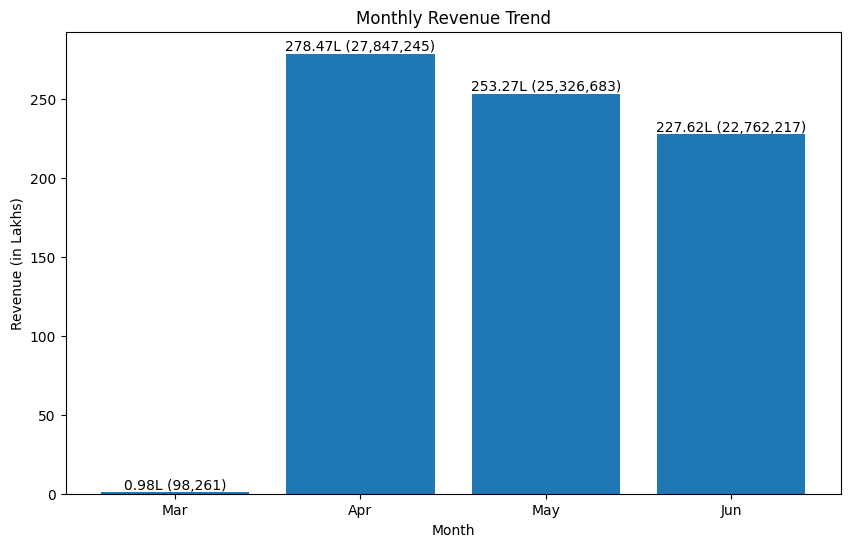

In [67]:
import matplotlib.pyplot as plt

months = [3, 4, 5, 6]
revenue = [98261, 27847245,25326683,22762217]

# Convert to Lakhs (1 Lakh = 100,000)
revenue_lakh = [val / 100000 for val in revenue]

plt.figure(figsize=(10,6))
bars = plt.bar(months, revenue_lakh)

# Labels like 25.92L
for bar, val in zip(bars, revenue):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{val/100000:.2f}L ({val:,})",
        ha='center',
        va='bottom'
    )
plt.xticks(months, ['Mar', 'Apr', 'May', 'Jun'])
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (in Lakhs)")

plt.show()


2. Total Quantity Sold

In [52]:
df["order_id"].nunique()

120378

In [53]:
category_orders = (
    df.groupby("category")["order_id"]
    .count()
    .sort_values(ascending=False)
    .reset_index()
)
category_orders

,category,order_id
0,Set,50284
1,kurta,49877
2,Western Dress,15500
3,Top,10622
4,Ethnic Dress,1159
5,Blouse,926
6,Bottom,440
7,Saree,164
8,Dupatta,3


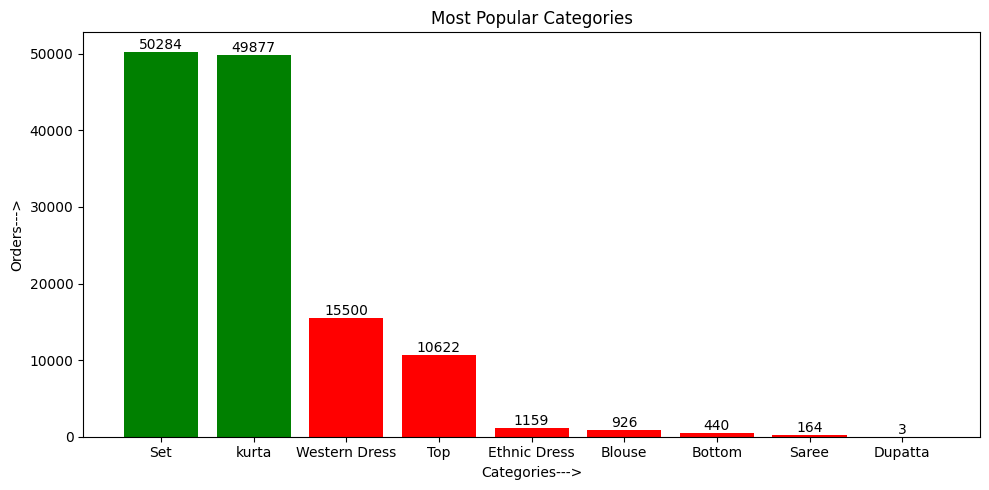

In [54]:
orders = [50284,49877,15500,10622,1159,926,440,164,3]
plt.figure(figsize=(10,5))
bars = plt.bar(category_orders["category"],category_orders["order_id"],color=["green" if i < 2 else "red" for i in range(len(category_orders["category"]))])
for bar, val in zip(bars, orders):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{val}",
        ha='center',
        va='bottom'
    )
plt.title("Most Popular Categories")
plt.xlabel("Categories--->")
plt.ylabel("Orders--->")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

3. Total Quantity Sold

In [55]:
df["qty"].value_counts()

qty
1     115780
0      12807
2        341
3         32
4          9
5          2
9          1
15         1
13         1
8          1
Name: count, dtype: int64

In [56]:
df["courier_status"].value_counts()

courier_status
Shipped      109487
Unshipped      6681
Cancelled      5935
Name: count, dtype: int64

In [57]:
max = df["amount"].max()
min = df["amount"].min()
mean = df["amount"].mean()
print(f"max = {max}\nmin = {min}\nmean = {mean}")

max = 5584.0
min = 0.0
mean = 648.5614647631622


In [58]:
quantity_sold = df["qty"].sum()
print("Total Quantity Sold: ",quantity_sold)

Total Quantity Sold:  116649


In [59]:
Total_demand = df.groupby("category")["qty"].sum().sort_values(ascending=False).reset_index()
Total_demand

,category,qty
0,Set,45289
1,kurta,45045
2,Western Dress,13943
3,Top,9903
4,Ethnic Dress,1053
5,Blouse,863
6,Bottom,398
7,Saree,152
8,Dupatta,3


In [60]:
category_orders = (
    df.groupby("category")["order_id"]
    .count()
    .sort_values(ascending=False)
    .reset_index()
)
category_orders

,category,order_id
0,Set,50284
1,kurta,49877
2,Western Dress,15500
3,Top,10622
4,Ethnic Dress,1159
5,Blouse,926
6,Bottom,440
7,Saree,164
8,Dupatta,3


In [61]:
order_frequency = df.groupby("category")["order_id"].nunique().sort_values(ascending=False).reset_index()
order_frequency


,category,order_id
0,Set,47845
1,kurta,46561
2,Western Dress,14994
3,Top,10155
4,Ethnic Dress,1148
5,Blouse,897
6,Bottom,410
7,Saree,144
8,Dupatta,2


In [62]:
category_by_quantity = df.groupby("category")["qty"].mean().sort_values(ascending=False).reset_index()
category_by_quantity

,category,qty
0,Dupatta,1.000000
1,Top,0.932310
2,Blouse,0.931965
3,Saree,0.926829
4,Ethnic Dress,0.908542
5,Bottom,0.904545
6,kurta,0.903122
7,Set,0.900664
8,Western Dress,0.899548


4. Average Order Value

In [63]:
aov = total_revenue/df["order_id"].nunique()
print("Average Order Value: ",aov.round(2))

Average Order Value:  652.88


5. Top 5 Categories that generated the highest Revenue

In [64]:
product_by_revenue = df.groupby("category")["revenue"].sum().sort_values(ascending=False).reset_index()
product_by_revenue.head(5)

,category,revenue
0,Set,37934434.0
1,kurta,20675349.0
2,Western Dress,10707932.0
3,Top,5242931.0
4,Ethnic Dress,762949.0
